In [1]:
import tensorflow as tf
print(f"Num Gpu Avaiable Are : {len(tf.config.list_physical_devices('GPU'))}")

Num Gpu Avaiable Are : 1


In [2]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import librosa
import librosa.display
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import plotly.figure_factory as ff
import seaborn as sns
import IPython
import tensorflow.keras.layers as L
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder,StandardScaler
import re
import itertools
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')


import os


In [3]:
df=pd.read_csv("processed_data.csv")
df.shape

(22760, 2377)

In [4]:
df=df.fillna(0)
print(df.isna().any())
df.shape

0            False
1            False
2            False
3            False
4            False
             ...  
2372         False
2373         False
2374         False
2375         False
Bird_Name    False
Length: 2377, dtype: bool


(22760, 2377)

In [5]:
X=df.drop(labels='Bird_Name',axis=1)
Y=df['Bird_Name']

In [6]:
from tensorflow.keras.utils import to_categorical

In [7]:
Y

0        Acridotherestristis
1        Acridotherestristis
2        Acridotherestristis
3        Acridotherestristis
4        Acridotherestristis
                ...         
22755             Upupaepops
22756             Upupaepops
22757             Upupaepops
22758             Upupaepops
22759             Upupaepops
Name: Bird_Name, Length: 22760, dtype: object

In [8]:
lb=LabelEncoder()
Y=to_categorical(lb.fit_transform(Y))
print(lb.classes_)
Y

['Acridotherestristis' 'Aegithaloscaudatus' 'Alaudaarvensis' 'Apusapus'
 'Cacicuscela' 'Cardueliscarduelis' 'Chlorischloris'
 'Coccothraustescoccothraustes' 'Columbalivia' 'Columbapalumbus'
 'Corvuscorone' 'Corvusfrugilegus' 'Cuculuscanorus' 'Delichonurbicum'
 'Dendrocoposmajor' 'Dumetellacarolinensis' 'Emberizacitrinella'
 'Erithacusrubecula' 'Ficedulahypoleuca' 'Fringillacoelebs' 'Gallusgallus'
 'Garrulusglandarius' 'Hirundorustica' 'Laniusexcubitor'
 'Luscinialuscinia' 'Motacillaalba' 'Motacillaflava' 'Parusmajor'
 'Passerdomesticus' 'Phoenicurusochruros' 'Phoenicurusphoenicurus'
 'Phylloscopuscollybita' 'Phylloscopustrochilus' 'Picapica'
 'Pycnonotuscafer' 'Pycnonotusjocosus' 'Sittaeuropaea'
 'Streptopeliaturtur' 'Sturnusvulgaris' 'Troglodytestroglodytes'
 'Turdusmerula' 'Turdusphilomelos' 'Turduspilaris' 'Upupaepops']


array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,Y,random_state=42,test_size=0.2,shuffle=True)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((18208, 2376), (4552, 2376), (18208, 44), (4552, 44))

In [10]:
X_train,X_val,y_train,y_val=train_test_split(X_train,y_train,random_state=42,test_size=0.1,shuffle=True)
X_train.shape, X_test.shape, X_val.shape, y_train.shape,y_test.shape,y_val.shape

((16387, 2376),
 (4552, 2376),
 (1821, 2376),
 (16387, 44),
 (4552, 44),
 (1821, 44))

In [11]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
X_val=scaler.transform(X_val)
X_train.shape,X_test.shape,X_val.shape,y_train.shape,y_test.shape,y_val.shape

((16387, 2376),
 (4552, 2376),
 (1821, 2376),
 (16387, 44),
 (4552, 44),
 (1821, 44))

In [12]:
import joblib
# Save the scaler to a file
scaler_path = './scaler.pkl'
joblib.dump(scaler, scaler_path)

['./scaler.pkl']

In [13]:
X_train=np.expand_dims(X_train,axis=2)
X_val=np.expand_dims(X_val,axis=2)
X_test=np.expand_dims(X_test,axis=2)
X_train.shape, X_test.shape, X_val.shape

((16387, 2376, 1), (4552, 2376, 1), (1821, 2376, 1))

In [14]:
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [15]:
early_stop = EarlyStopping(monitor='val_accuracy', mode='max', patience=5, restore_best_weights=True)
lr_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience=3, verbose=1, factor=0.5, min_lr=0.00001)


In [16]:
EPOCH=50
BATCH_SIZE=64

In [18]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.mixed_precision import set_global_policy

# Enable mixed precision for lower memory consumption and faster computation on GPU
set_global_policy('mixed_float16')

def residual_block(x, filters, kernel_size, dilation_rate):
    # Causal convolution
    conv_filter = layers.Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    conv_filter = layers.Activation('tanh')(conv_filter)

    conv_gate = layers.Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    conv_gate = layers.Activation('sigmoid')(conv_gate)

    # Element-wise multiplication of the tanh and sigmoid activations
    x = layers.Multiply()([conv_filter, conv_gate])

    # 1x1 convolution for residual connection
    skip_connection = layers.Conv1D(filters, 1)(x)

    # Add the input (residual connection)
    out = layers.Add()([skip_connection, x])

    return out, skip_connection

def build_wavenet_model(input_shape, num_classes, num_blocks=3, num_layers_per_block=10, filters=64, kernel_size=2):
    inputs = layers.Input(shape=input_shape)
    x = inputs
    
    # Initial causal convolution
    x = layers.Conv1D(filters, kernel_size, padding='causal')(x)
    
    skip_connections = []
    
    # Stack of residual blocks
    for b in range(num_blocks):
        for i in range(num_layers_per_block):
            dilation_rate = 2 ** i  # Exponentially increasing dilation rate
            x, skip_connection = residual_block(x, filters, kernel_size, dilation_rate)
            skip_connections.append(skip_connection)
    
    # Sum all skip connections
    x = layers.Add()(skip_connections)
    
    # Global average pooling to collapse the time dimension
    x = layers.GlobalAveragePooling1D()(x)
    
    # Dense layer for classification
    x = layers.Dense(64, activation='relu')(x)
    
    # Output layer (for multi-class classification with softmax)
    x = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    # Create model
    model = Model(inputs, x)
    
    return model

# Define model parameters
input_shape = (2376, 1)  # Example shape (time steps, 1 for mono audio)
num_classes = 44  # Example number of bird species

# Build the Wavenet model
model = build_wavenet_model(input_shape, num_classes)

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Display the model summary
model.summary()

# Train the model (assuming you have prepared your data in `X_train`, `y_train`, `X_val`, `y_val`)
history = model.fit(X_train, y_train, epochs=30, batch_size=16, validation_data=(X_val, y_val),callbacks=[early_stop,lr_reduction])


Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_2 (InputLayer)            [(None, 2376, 1)]    0                                            
__________________________________________________________________________________________________
conv1d_91 (Conv1D)              (None, 2376, 64)     192         input_2[0][0]                    
__________________________________________________________________________________________________
conv1d_92 (Conv1D)              (None, 2376, 64)     8256        conv1d_91[0][0]                  
__________________________________________________________________________________________________
conv1d_93 (Conv1D)              (None, 2376, 64)     8256        conv1d_91[0][0]                  
____________________________________________________________________________________________

In [19]:
model_path = "./wavnet.h5"

model.save(model_path)

In [20]:
fig=px.line(history.history,y=['accuracy','val_accuracy'],
           labels={'index':'epoch','value':'accuracy'},
           title=f'According to the epoch accuracy and validation accuracy chart for the model')
fig.show()

In [21]:
fig=px.line(history.history,y=['loss','val_loss'],
           labels={'index':'epoch','value':'loss'},
           title=f'According to the epoch loss and validation loss chart for the model')
fig.show()

In [22]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_pred

array([17,  6, 32, ...,  7, 36, 25], dtype=int64)

In [23]:
y_check=np.argmax(y_test,axis=1)
y_check

array([38,  6, 32, ...,  7, 36, 25], dtype=int64)

In [24]:
loss,accuracy=model.evaluate(X_test,y_test,verbose=0)
print(f'Test Loss: {loss}')
print(f'Test Accuracy: {accuracy}')

Test Loss: 1.6489558219909668
Test Accuracy: 0.5612917542457581


In [26]:
emotion_names=df['Bird_Name'].unique()

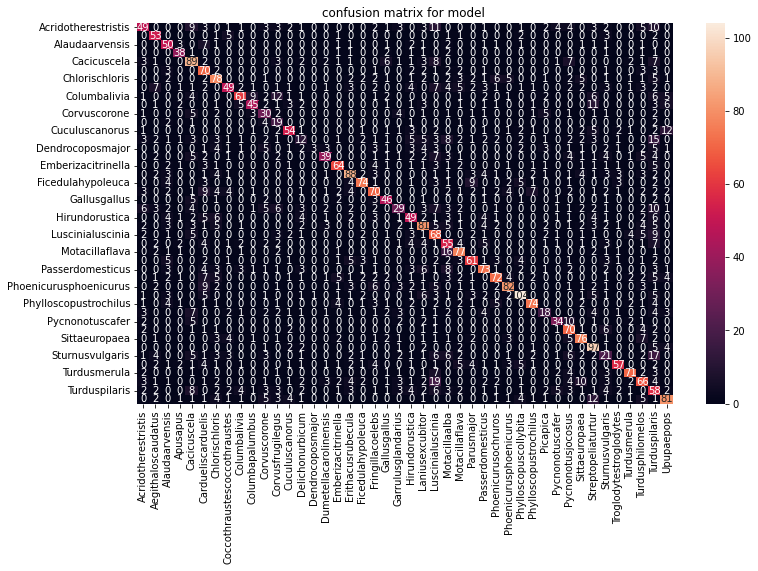

In [27]:
conf=confusion_matrix(y_check,y_pred)
cm=pd.DataFrame(
    conf,index=[i for i in emotion_names],
    columns=[i for i in emotion_names]
)
plt.figure(figsize=(12,7))
ax=sns.heatmap(cm,annot=True,fmt='d')
ax.set_title(f'confusion matrix for model ')
plt.show()

In [28]:
print(f'Model Confusion Matrix\n',classification_report(y_check,y_pred,target_names=emotion_names))

Model Confusion Matrix
                               precision    recall  f1-score   support

         Acridotherestristis       0.56      0.40      0.46       124
          Aegithaloscaudatus       0.59      0.77      0.67        69
              Alaudaarvensis       0.51      0.66      0.57        76
                    Apusapus       0.69      0.76      0.72        50
                 Cacicuscela       0.53      0.63      0.58       141
          Cardueliscarduelis       0.46      0.75      0.57        93
              Chlorischloris       0.56      0.60      0.58       129
Coccothraustescoccothraustes       0.64      0.44      0.52       112
                Columbalivia       0.72      0.52      0.60       117
             Columbapalumbus       0.70      0.49      0.58        91
                Corvuscorone       0.40      0.48      0.44        62
            Corvusfrugilegus       0.26      0.63      0.37        30
              Cuculuscanorus       0.69      0.56      0.62      

In [18]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.mixed_precision import set_global_policy

# Enable mixed precision for lower memory consumption and faster computation on GPU
set_global_policy('mixed_float16')

# Define the LSTM model
model = Sequential([
    LSTM(256, return_sequences=True, input_shape=(2376, 1), activation='tanh', recurrent_activation='sigmoid'),
    Dropout(0.1),  
    BatchNormalization(),
    LSTM(128, return_sequences=True, activation='tanh', recurrent_activation='sigmoid'),
    Dropout(0.1),
    BatchNormalization(),
    LSTM(128, return_sequences=True, activation='tanh', recurrent_activation='sigmoid'),
    LSTM(64, activation='tanh', recurrent_activation='sigmoid'),
    Dropout(0.1),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dense(44, activation='softmax', dtype='float32')  # Ensure final layer uses float32 for numerical stability
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Display the model summary
model.summary()

# Train the model with reduced batch size
history = model.fit(X_train, y_train, epochs=20, batch_size=16, validation_data=(X_val, y_val))


Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_4 (LSTM)                (None, 2376, 256)         264192    
_________________________________________________________________
dropout_3 (Dropout)          (None, 2376, 256)         0         
_________________________________________________________________
batch_normalization_3 (Batch (None, 2376, 256)         1024      
_________________________________________________________________
lstm_5 (LSTM)                (None, 2376, 128)         197120    
_________________________________________________________________
dropout_4 (Dropout)          (None, 2376, 128)         0         
_________________________________________________________________
batch_normalization_4 (Batch (None, 2376, 128)         512       
_________________________________________________________________
lstm_6 (LSTM)                (None, 2376, 128)        

In [19]:
model_path = "./lstm.h5"

model.save(model_path)

In [20]:
fig=px.line(history.history,y=['accuracy','val_accuracy'],
           labels={'index':'epoch','value':'accuracy'},
           title=f'According to the epoch accuracy and validation accuracy chart for the model')
fig.show()

In [21]:
fig=px.line(history.history,y=['loss','val_loss'],
           labels={'index':'epoch','value':'loss'},
           title=f'According to the epoch loss and validation loss chart for the model')
fig.show()

In [22]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_pred

array([22,  0, 39, ..., 42,  8,  6], dtype=int64)

In [23]:
y_check=np.argmax(y_test,axis=1)
y_check

array([38,  6, 32, ...,  7, 36, 25], dtype=int64)

In [24]:
loss,accuracy=model.evaluate(X_test,y_test,verbose=0)
print(f'Test Loss: {loss}')
print(f'Test Accuracy: {accuracy}')

Test Loss: 2.969982385635376
Test Accuracy: 0.18804921209812164


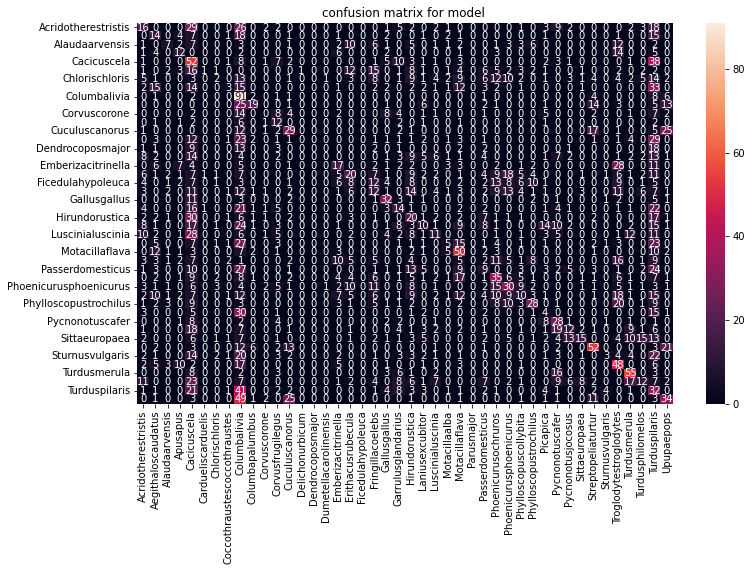

In [27]:
conf=confusion_matrix(y_check,y_pred)
cm=pd.DataFrame(
    conf,index=[i for i in emotion_names],
    columns=[i for i in emotion_names]
)
plt.figure(figsize=(12,7))
ax=sns.heatmap(cm,annot=True,fmt='d')
ax.set_title(f'confusion matrix for model ')
plt.show()

In [28]:
print(f'Model Confusion Matrix\n',classification_report(y_check,y_pred,target_names=emotion_names))

Model Confusion Matrix
                               precision    recall  f1-score   support

         Acridotherestristis       0.15      0.13      0.14       124
          Aegithaloscaudatus       0.14      0.20      0.16        69
              Alaudaarvensis       0.28      0.09      0.14        76
                    Apusapus       0.24      0.24      0.24        50
                 Cacicuscela       0.11      0.37      0.17       141
          Cardueliscarduelis       0.33      0.01      0.02        93
              Chlorischloris       0.13      0.02      0.03       129
Coccothraustescoccothraustes       0.20      0.03      0.05       112
                Columbalivia       0.14      0.78      0.24       117
             Columbapalumbus       0.51      0.21      0.30        91
                Corvuscorone       0.00      0.00      0.00        62
            Corvusfrugilegus       0.16      0.40      0.23        30
              Cuculuscanorus       0.30      0.30      0.30      